<p align="center">
<img src="opticare_logo_small.png" width="180">
</p>

<h1 align="center">Predicting Medical Insurance Charges Using Demographic and Lifestyle Factors</h1>

<h3 align="center">Opticare Insurance Company</h3>

<p align="center">
Machine Learning Model for Estimating Customer Insurance Charges
</p>




PROJECT OVERVIEW

This project develops a supervised machine learning model to predict individual medical insurance charges based on demographic and lifestyle attributes.

The model uses the following features:

- Age
- Body Mass Index (BMI)
- Number of Children
- Smoking Status
- Geographic Region

The target variable is 'charges', representing the medical insurance cost billed to the customer.

IMPORT LIBRARIES NECESSARY FOR THE ANALYSIS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Insurance_dataset.csv')

DATA PREPROCESSING

--Checking the data quality and getting it ready for the model's training and testing






DATA EXPLORATION
  --Exploring the dimentionality of the data

  This helps to gain insights into the data

In [ ]:
df.head()

# Shows the first-five rows of the dataset, with the 7 columns in the data.
# First-six columns are the 'features' while 'charges' is the 'label or target' for prediction

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.tail()

# Shows the last-five rows of the data
# exploring and familiarizing with the dataset
# we can see different age of the clients, their gender - male or female as in the dataset, some clients have children and others do not
# some clients are smokers represented by 'yes', 'no' for non-smokers
# The customers live in different regions of the country: northwest, northeast, southeast and southwest

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
df.sample(5)

# selects random sample each time
# still examining the dataset to see they're in rightful formats

,age,sex,bmi,children,smoker,region,charges
680,21,female,17.40,1,no,southwest,2585.26900
1263,43,female,29.90,1,no,southwest,7337.74800
1331,23,female,33.40,0,no,southwest,10795.93733
290,28,female,33.40,0,no,southwest,3172.01800
600,18,female,39.16,0,no,southeast,1633.04440


In [ ]:
df.shape

(1338, 7)

In [ ]:
# shows the number of rows and columns contained in the entire data. It tells the size of the data
# The dataset contains 1,338 rows, 7 columns
# size of the data helps in building a better predictive model. Better to have more rows

In [ ]:
df.columns

# exploring the column names to see if there is 'whitespace'

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

INVESTIGATE / EXPLORE DATA STRUCTURES

  -- Investigate the dataset for annormalies and data types

  -- Investigate for missing values









In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The output of RangeIndex 1338 entries and Total 7 columns, corresponds with the output with df.shape. Also with the last row in df.tail This entails there are no missing values in this dataset.

Another insight from the above is 'Dtype' this shows the datatypes of each feature. The columns: sex, smoker, region, are in 'object' datatype, that is they are 'strings'.

Since the machine learning models only executes numbers, and the insurance premium prediction to be done is a numeric operation, these categorical columns will be converted to numeric so that the prediction model can be executed properly

In [ ]:
df.isnull().sum()

# confirming there are no missing values in the dataset

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(1)

 One duplicate is found and it is dropped.

 But further investigation is made in the following steps before dropping it

In [ ]:
df[df.duplicated()]

# investigating which row is duplicated (row 581 is duplicated)

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
df[df['charges'] == 1639.5631]

# the 'charges' column appears to be the column with the most precise and unique information for this investigation
# the investigation reveals the 2 rows having exact information are 195 and 581

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df.duplicated().sum()

np.int64(1)

The duplicate is still in the dataset. 'inplace=True' will be used to ensure the duplicate has been removed

In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

MULTICOLLINEARITY

-- when 2 or more independent features in the regression model are highly correlated. This makes the model coefficients to be unstable and difficult for the model to interpret, and would lead to poor performance of the model


-- If 2 features are highly correlated, 1 is dropped so to improve the model's predictive strength


-- Correlation can only be carried out on numerical variables. Therefore, numerical variables are filtered, and correlation applied on them

In [ ]:
df.select_dtypes(include=np.number).corr()

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


The output shows that no multicollinearity exist within the features. The features are not strongly correlated, therefore all the features are good enough to be used in training the regression model

DEFINING THE FEATURES AND TARGET


X = features

y = target or label

In [ ]:
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df['charges']

In [ ]:
X

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [ ]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


ENCODING CATEGORICAL FEATURES

Since Machine Learning do not take Strings(Objects) as input, the Categorical features will be converted to numerical.

The categorical features are sex, smoker, region. These categorical features have previously been defined as X. Refer above. Pandas method called 'pd.get_dummies' is used to encode categorical variables.

In [ ]:
X_encoded = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)
X_encoded

# drop_first=True creates a baseline for each of the categorial features, and uses the baseline to create new columns
# this creates new columns refered to as 'One-Hot-Encoding'

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,True,False,True,False,False
1334,18,31.920,0,False,False,False,False,False
1335,18,36.850,0,False,False,False,True,False
1336,21,25.800,0,False,False,False,False,True


In [ ]:
X_encoded.columns

Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

TRAIN_TEST_SPLIT


-- This operation splits the dataset into 2 sets: Training set and Testing set
-- Training set has a higher portion of 80% so the model has enough information to learn the pattern from. And Testing set 20% to test the model's actual understandability of the process and pattern to ensure the model did not overfit, thereby enabling the model to perform well in making prediction for the insurance charges

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train,y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

SCALING OR STANDARDIZING THE FEATURES

--This process is particularly crucial as it converts the Features to a common comparable scale. Enabling equal
contribution without allowing Features with larger magnitude to dominate the Features with less magnitude or numbers. This means that having different scales will distort the model's learning.
since computers see numbers as distance-based, the model will for instance in the context of this dataset attribute more importance to features with higher numbers than features with less numbers. Eg it would attribute more importance to age and bmi than children, but which is wrong. For this therefore, scaling has to be done. Standardize the features so that they're all on the same measurement or scale.
Inorder to determine which scale suits best, the data distribution is first visualized

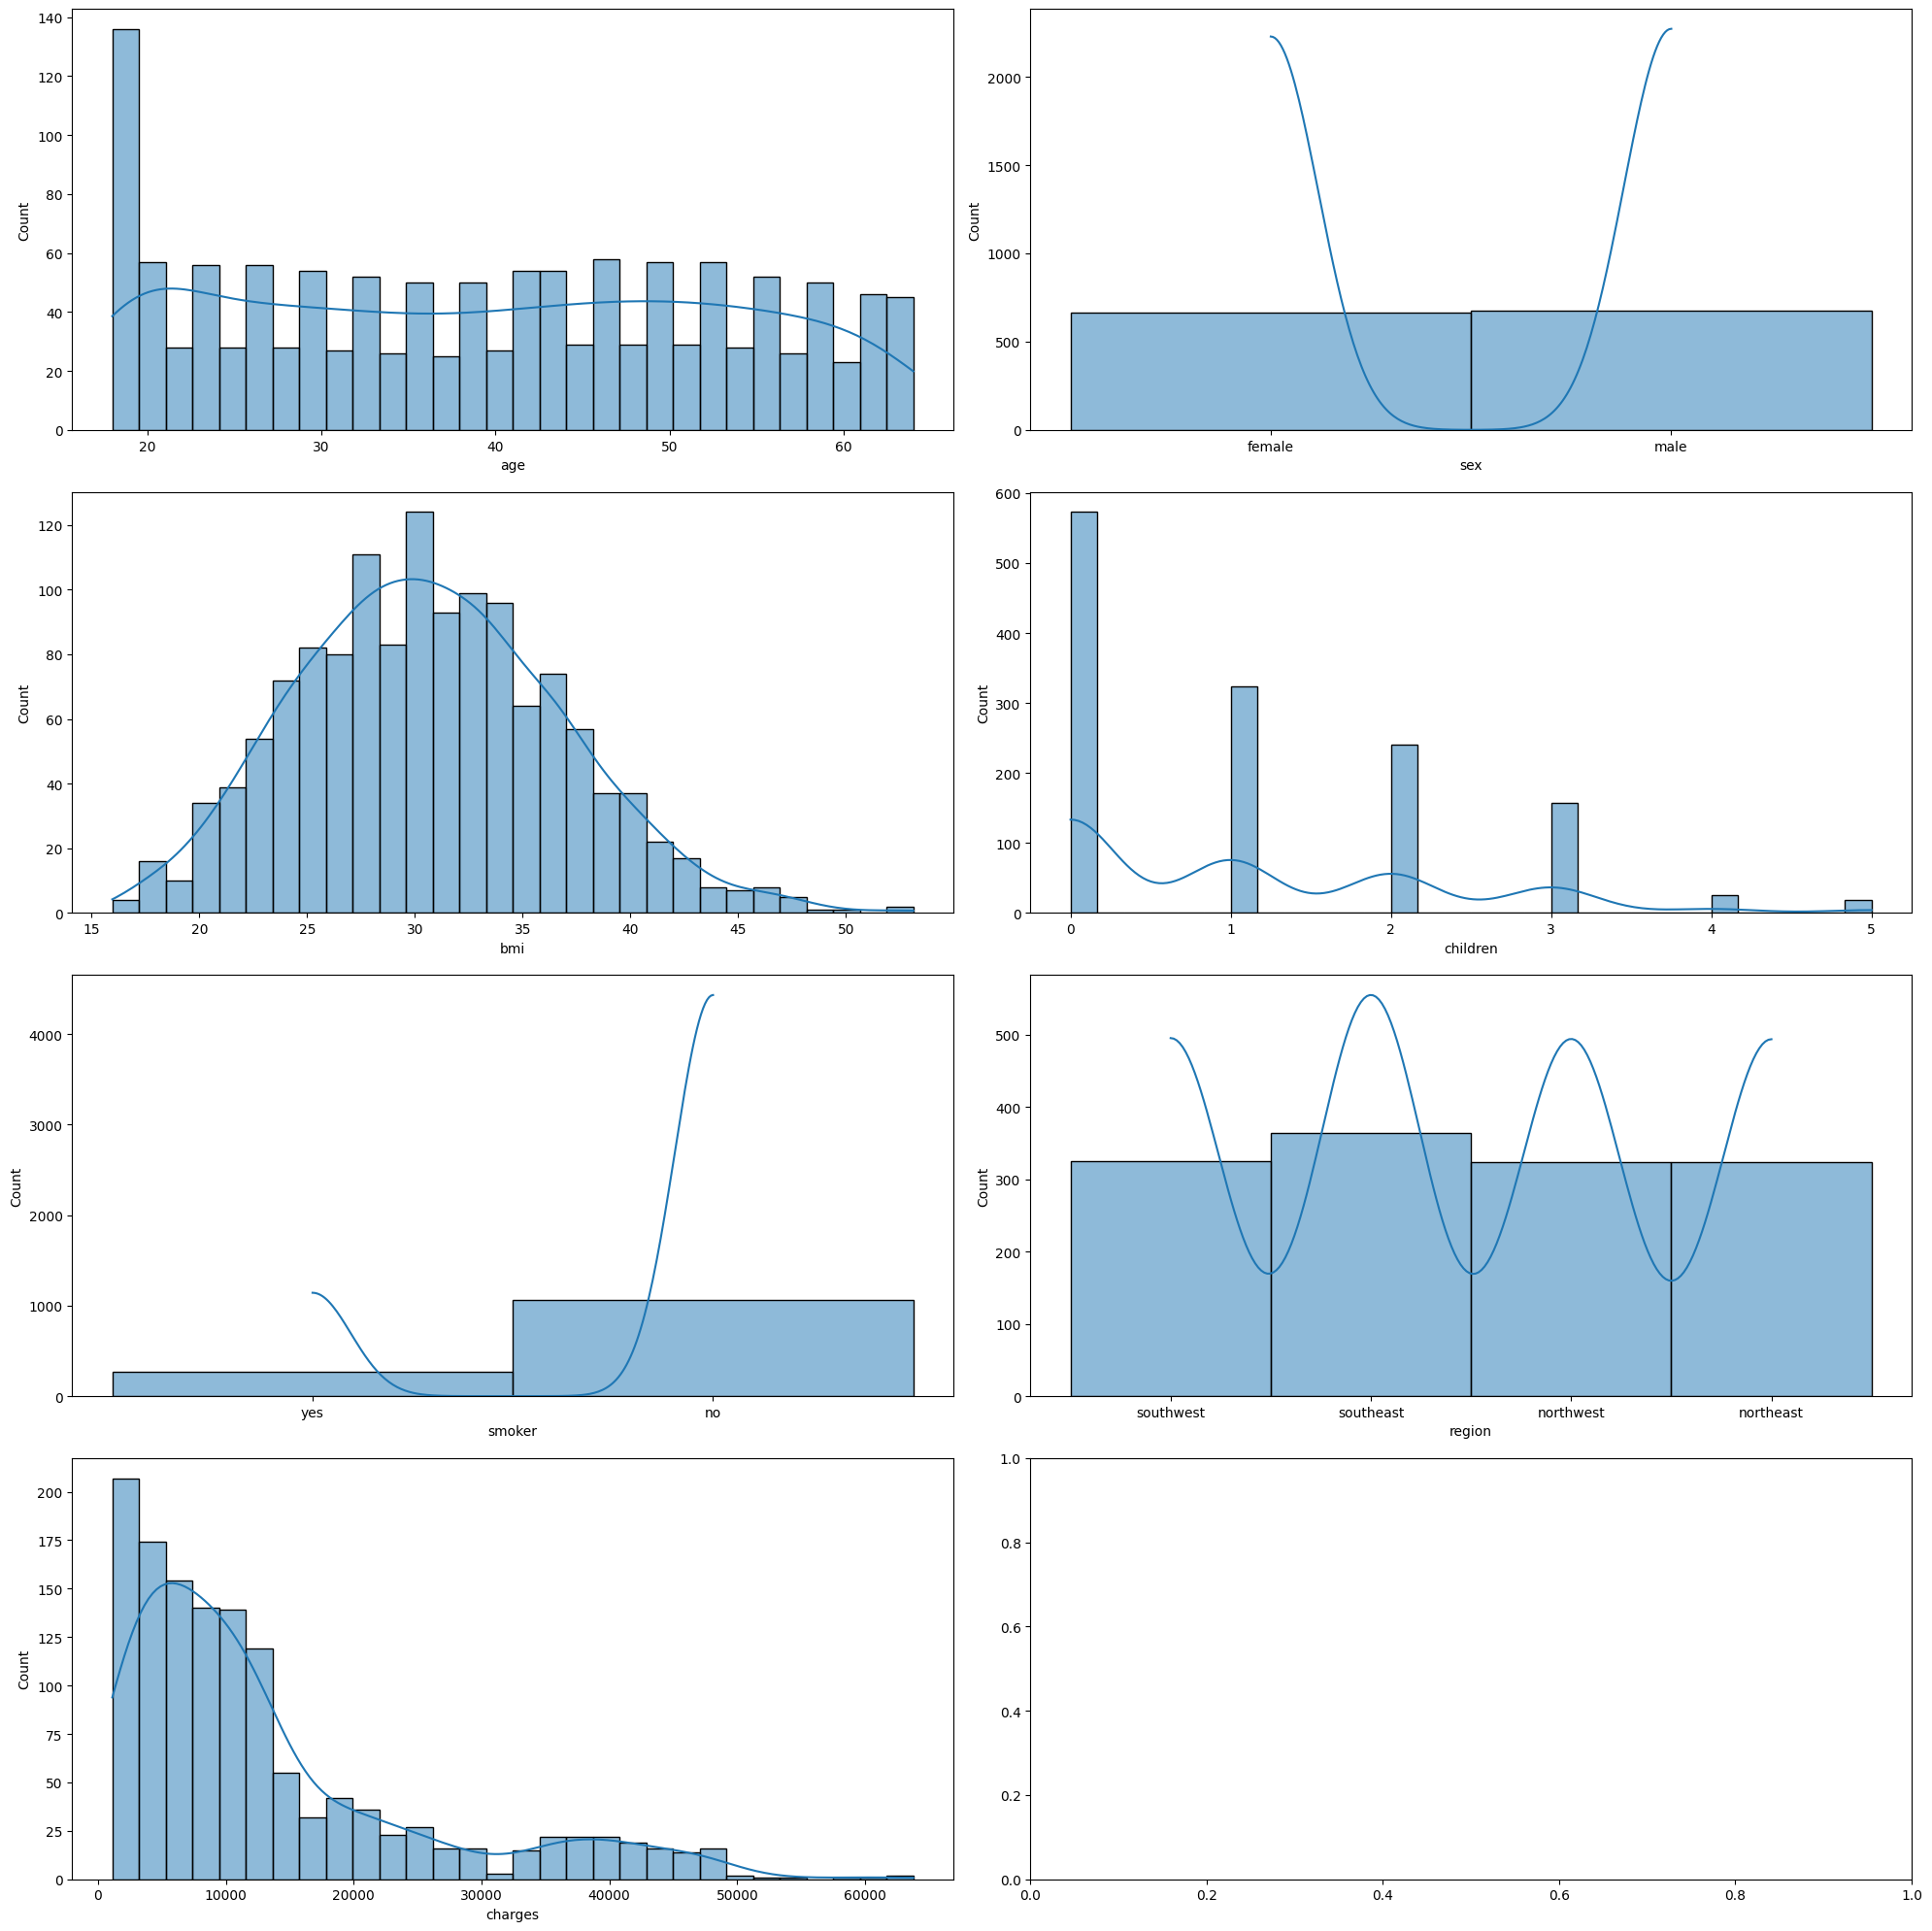

In [ ]:
fig, ax = plt.subplots(4, 2, figsize=(20, 20))
ax = ax.flatten()

for idx, col in enumerate(df):
    sns.histplot(df[col], kde=True, bins=30, ax=ax[idx])

plt.tight_layout()
plt.show()

INTERPRETATION OF THE VISUALS


The shape of the visuals show that the data is skewed across almost all the features. Indicating presence of outliers. Therefore, the RobustScaler will be used in scaling the data. This uses the Median and Interquartile Range(IQR) to scale the data which makes it resilient to outliers and heavy skewness, and will help in preventing extreme values from disproportionately influencing the scaling process.




Note that the Categorical features (sex, smoker and region) have already been converted to numerical (0/1) via one-hot encoding, and no further scaling may be necessary.
Numerical features with skewness(age, bmi, children) are appropriately scaled using RobustScaler to make them robust to outliers.

INSTANTIATE THE SCALER

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

FITTING THE DATA INTO THE REGRESSION MODEL

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
pd.DataFrame(X_train_scaled, columns=X_encoded.columns)

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-0.666667,-0.689697,-0.5,0.0,0.0,0.0,0.0,0.0
1,-0.750000,-0.540000,0.5,0.0,0.0,0.0,0.0,0.0
2,0.541667,0.887879,0.5,-1.0,0.0,1.0,0.0,0.0
3,1.000000,1.366061,-0.5,0.0,0.0,0.0,1.0,0.0
4,0.333333,-0.436364,0.5,-1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1064,0.500000,0.576970,0.5,-1.0,1.0,0.0,0.0,0.0
1065,-0.500000,1.903030,0.5,0.0,0.0,0.0,0.0,1.0
1066,-0.791667,-0.993939,0.0,0.0,0.0,0.0,0.0,1.0
1067,-0.041667,-0.266667,1.0,-1.0,0.0,0.0,0.0,1.0


MODELING


This project is to predict the insurance premium the Insurance Company(Policyholder) will charge their customers (Insurees). Linear regression model will be used to make this prediction because the outcome is numeric

In [ ]:
from sklearn.linear_model import LinearRegression

CREATE AN INSTANCE OF THE LINEAR REGRESSION CLASS

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train_scaled, y_train)

LinearRegression()

MODEL EVALUATION

Coefficient and Intercepts -- Evaluate and interpret model's performance

In [ ]:
coef = model.coef_
intercept = model.intercept_
print(f'Coefficients: {coef}')
print(f'Intercept: {intercept}')

Coefficients: [ 5957.05728539  2629.28688786  1066.0199776   -101.54205399
 23077.76459287  -391.76145478  -838.91961573  -659.13975155]
Intercept: 8643.817244386912


RESULT INTERPRETATION

Coefficients:

In a linear regression model, the coefficients quantify the impact of each feature on the target variable (in this case, 'charges').
Each Coefficient quantifies the impact of a 'one-unit change' in that respective feature, while holding everything else constant.
The signs show the direction, while the values highlight magnitude and strength

This allows us to understand the independent contribution of each feature to the model's prediction.





Intercept (8,643.81)

The intercept represents the predicted insurance charge when all features(predictors) are zero. This means that the baseline charge for the insurance is 8,643.81 dollars

FEATURE'S COEFFICIENTS INTERPRETATION






age: +5957.05

This positive coefficient indicates that, holding all other factors constant, an increase in `age`is associated with a significant increase of about 5,957 dollars in predicted insurance charges. This aligns with common insurance risk assessments, where older individuals typically face higher premiums.



bmi: +262

A positive coefficient of 2,629.28 for `bmi` suggests that, as body max indices increases, the predicted insurance charges also tend to rise. Higher BMI is often linked to increased health risks, which translates to higher insurance costs.


children: +1066.01

This implies that having more children has an implication of an increase in predicted insurance charges by 1,066.01 dollars. This could reflect the additional healthcare needs or family coverage often associated with having dependents.


    
sex_male: -101.54

The negative coefficient for 'sex_male' indicates that, relative to the female baseline, males are predicted to have slightly lower insurance charges of 101.54 dollars. However, the magnitude is relatively small, suggesting a minor impact compared to other features.


smoker_yes: +23077.76

This is the most impactful coefficient. The large positive value for 'smoker_yes' indicates that being a smoker dramatically increases predicted insurance charges compared to being a non-smoker, holding all other factors constant. This is a critical insight, highlighting smoking as the strongest predictor of high premiums in this model.


region_northwest: -391.76'

Compared to the baseline Northeast region, residing in the Northwest is associated with a slight decrease in predicted insurance charges by 391.76 dollars.


region_southeast: -838.92

Compared to the Northeast, individuals residing in the Southeast are predicted to have lower insurance charges, with a more substantial decrease than the Northwest region. Customers living in region_southeast pays the lowest insurance fee.


region_southwest: -659.14

Similar to the other regions relative to the Northeast, residing in the Southwest is associated with a decrease in predicted insurance charges, falling between the Northwest and Southeast in terms of magnitude of reduction.
Meaning that clients in southwest are charged the second lowest fees.



  Key Takeaways:

Smoking is the Dominant Factor: The 'smoker_yes' feature has by far the largest coefficient, making it the most significant determinant of insurance charges in this model.


Age and BMI are Strong Predictors: 'age' and 'bmi' also have substantial positive impacts on charges, consistent with health-related risk factors.


Regional Variation: There are observable differences in predicted charges across regions, with the Northeast serving as the higher-cost baseline.


This detailed interpretation provides valuable insights into how each characteristic influences insurance premiums, offering a clear understanding for stakeholders and demonstrating a robust analytical approach for potential employers.

In [ ]:
len(X_train_scaled)

# The model has now learned from 1,069 clients. Their age, sex, their bmi, whether they're smokers or not, whether they have children or not, the region where they reside, and the insurance premium each of them is charged
# The model has learned the pattern, the relationship that exist between the above mentioned features and how much they're charged for the insurance premium. So, the dependent variable (charges) is determined or influenced by the independent variables (the features)

1069

In [ ]:
len(X_test_scaled)

# Now it's time to test to see if the model really learned correctly
# The model's understandability will be tested by requesting it to predict the insurance charges of the remaining 268 clients which it was not allowed to see

268

In [ ]:
prediction = model.predict(X_test_scaled)

In [ ]:
pd.Series(prediction)

# The 268 rows have now been predicted by the mode

,0
0,8143.693884
1,5737.115683
2,14369.314876
3,31745.513636
4,8962.386657
...,...
263,16753.406458
264,15274.565769
265,6454.699355
266,38467.156720


RESIDUAL OR ERROR ANALYSIS


Analyse the residuals to access the model's performance
--Evaluating to what extent the model got it wrong by

In [ ]:
residual = y_test - prediction

y_test = Actual Charges

prediction = Predicted Charges

residual = Residual

In [ ]:
prediction_df = pd.DataFrame({'Actual Charges': y_test, 'Predicted Charges': prediction, 'Residual': residual})
prediction_df

,Actual Charges,Predicted Charges,Residual
900,8688.85885,8143.693884,545.164966
1064,5708.86700,5737.115683,-28.248683
1256,11436.73815,14369.314876,-2932.576726
298,38746.35510,31745.513636,7000.841464
237,4463.20510,8962.386657,-4499.181557
...,...,...,...
534,13831.11520,16753.406458,-2922.291258
542,13887.20400,15274.565769,-1387.361769
760,3925.75820,6454.699355,-2528.941155
1284,47403.88000,38467.156720,8936.723280


RESIDUALS PLOT

--To show how the difference between the Actual Charges and the Predicted Charges are distributed

Text(0, 0.5, 'Frequency')

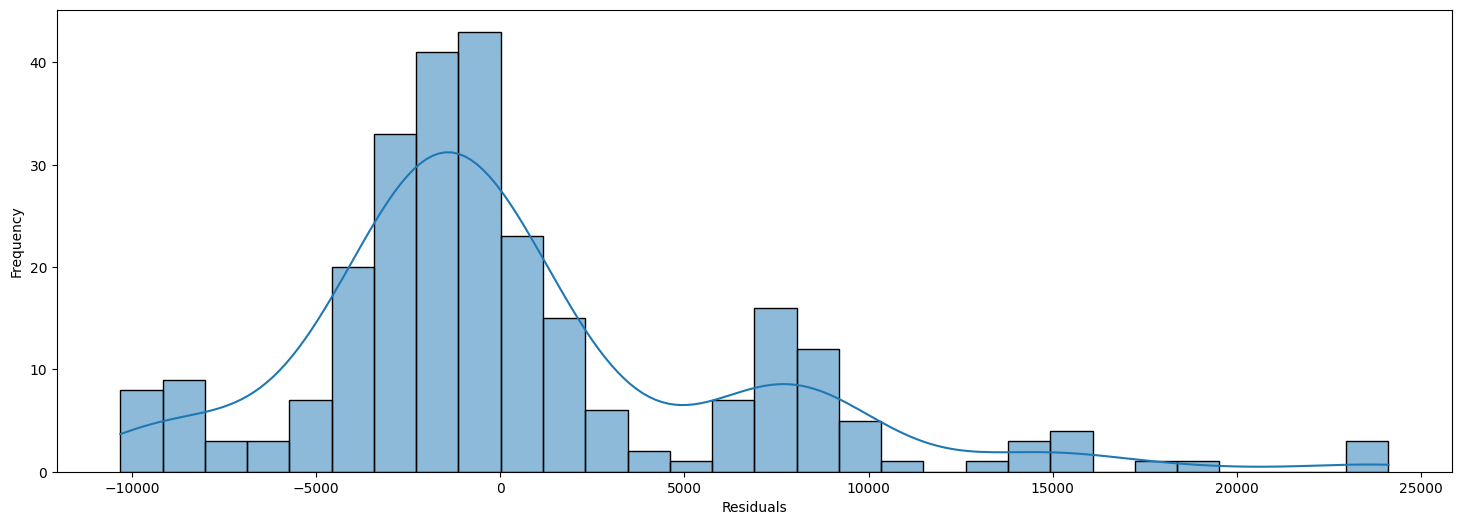

In [ ]:
plt.figure(figsize=(18,6))
sns.histplot(residual, kde=True, bins=30)
plt.xlabel('Residuals')
plt.ylabel('Frequency')


--Relatively normal distribution


The plot above visualizes the distribution of the residuals, which represents the differences between the Actual Charges(y_test) and the model's Predicted Charges(prediction). Analysing this plot is crucial for assessing the performance and validity of a Linear Regression Model.


Key observations and Implications:
The residuals are centered around zero and show a normal-like distribution. This is a desirable characteristics as it indicates that the model is not systemmatically over-predicting or under-predicting the insurance charges.

While not perfectly normal, the bell-like shape suggests that the majority of the predictions are close to the actual values, with larger errors occurring less frequently. It suggests an unbiased and well-performing linear regression model whose errors are random, thus boosting confidence in its predictive ability.

MODEL PERFORMANCE EVALUATION

--Using common regression matrics to evaluate how well the model performed

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
mae = mean_absolute_error(y_test, prediction)
mse = mean_squared_error(y_test, prediction)
r2 = r2_score(y_test, prediction)

In [ ]:
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {np.sqrt(mse)}')
print(f'R2 Score: {r2}')

Mean Absolute Error: 4177.045561036324
Root Mean Squared Error: 5956.342894363587
R2 Score: 0.8069287081198012


INTERPRETING THE MODEL'S METRICS WHEN ROBUST SCALER WAS USED


1. Mean Absolute Error(MAE) = 4,177
This result entails that the model's prediction deviates from the Actual charges by an average of 4,177 dollars in absolute terms. What this implies is that the MAE provides a measurable error in the amount of dollars the deviation occurs, making it easier for Stakeholders to understand and plan with


2. Root Mean Squared Error(RMSE) = 5,956.34
This metric penalizes larger error more than the MAE as a result of the squaring difference. The difference between RMSE and MAE suggests the presence of higher-magnitude prediction errors or outliers, likely driven by charges outliers or higher insurance charges.


3. R²(R-Squared) = 80.6%
The interpretation of this is that the model explains 80.6% of the variaance in the insurance charges based on the data provided in the features. This indicates accuracy and reliability of the coefficients.
This is a strong result, indicating that the model captures most of the important factors influencing insurance charges.
However, the remaining ~19.4% unexplained variance may be attributable to market stochasticity, or possibily due to randomness and uncertainty in a system, process or economic trends, etc.

USING ANOTHER SCALER FOR COMPARISON

In [ ]:
from sklearn.preprocessing import StandardScaler

INITIALIZE THE SCALER

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
prediction = model.predict(X_test_scaled)

In [ ]:
prediction

# The prediction is in array. To make it readable and understandable, it'll be converted to pandas dataframe in the next cell

array([ 8.14369388e+03,  5.73711568e+03,  1.43693149e+04,  3.17455136e+04,
        8.96238666e+03,  1.31497224e+04,  3.04467607e+04,  1.45328881e+03,
        1.06330184e+04,  1.13189438e+04,  1.03778536e+04,  3.31184377e+04,
        3.10772527e+04,  1.74119253e+04,  1.08016743e+04,  9.52889964e+03,
        4.16103784e+03,  3.17315373e+04,  3.21938875e+03,  5.22992460e+03,
        3.54979004e+03,  3.02837740e+04,  1.48989509e+04,  3.04569093e+04,
        3.11077668e+04,  5.51196081e+03,  3.55030401e+04,  3.65704810e+04,
        1.14123133e+04,  1.42056990e+04,  6.50234029e+03,  1.27246945e+04,
        3.99806590e+02,  1.20883980e+04,  3.96592069e+04,  1.23395540e+04,
        4.74412279e+03,  3.91903157e+03,  3.08606789e+04,  8.95870663e+03,
        7.05389441e+03,  3.01125636e+04,  3.47804324e+04,  1.22916189e+04,
        7.35739310e+03,  3.42060530e+03,  6.21243471e+03,  8.98345200e+03,
        4.26401828e+03,  9.01992870e+03,  6.60149578e+03,  1.20802337e+04,
        3.12447687e+04,  

In [ ]:
pd.Series(prediction)

,0
0,8143.693884
1,5737.115683
2,14369.314876
3,31745.513636
4,8962.386657
...,...
263,16753.406458
264,15274.565769
265,6454.699355
266,38467.156720


Calculate the metrics to see if there is any difference in performance between RobustSclaer and StandardScaler

In [ ]:
np.sqrt(mean_squared_error(y_test, prediction))


np.float64(5956.342894363589)

OBSERVATION

RMSE(Root Mean Squared Error):

RobustScaler = 5956.342894363587

StandardScaler = 5956.342894363589

There is no significant difference between the RobustScaler and StandardScaler in this dataset. The difference lies within the precision in the number prefix and the difference is 000002

Practically, a lower RMSE is better since it indicates more accuracy. Meaning that the model's predictions are closer to the actual values. Model with lower RMSE means a better forecast, which ultimately leads to better decision making.

In [ ]:
mae = mean_absolute_error(y_test, prediction)
mse = mean_squared_error(y_test, prediction)
r2 = r2_score(y_test, prediction)

In [ ]:
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {np.sqrt(mse)}')
print(f'R2 Score: {r2}')

Mean Absolute Error: 4177.045561036326
Root Mean Squared Error: 5956.342894363589
R2 Score: 0.8069287081198011


EXPERIMENTING ANOTHER MODEL --RIDGE

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
ridge_model = Ridge()

ridge_model.fit(X_train_scaled, y_train)

Ridge()

In [ ]:
ridge_prediction = ridge_model.predict(X_test_scaled)

In [ ]:
np.sqrt(mean_squared_error(y_test, ridge_prediction))

np.float64(5959.234416290865)

In [ ]:
mae = mean_absolute_error(y_test, ridge_prediction)
mse = mean_squared_error(y_test, ridge_prediction)
r2 = r2_score(y_test, ridge_prediction)

In [ ]:
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {np.sqrt(mse)}')
print(f'R2 Score: {r2}')

Mean Absolute Error: 4179.621622409952
Root Mean Squared Error: 5959.234416290865
R2 Score: 0.8067412087126403


  COMPARISON BETWEEN LINEAR REGRESSION MODEL AND RIDGE

  RMSE:

      Linear Regression, RobustScaler = 5956.342894363587

      Ridge = 5959.234416290865

  

Conclusively, R2 is the coefficient of determination. R2 is the same across board with 80.6% in all the metrics. The R2 shows how well the models explain the factors(features) in the dataset in relation with the target(charge)

MSE indicates how much the error predictions were squared on the average. That is, the difference between Actual and Predicted and squared, just so to magnify the error to call attention

RMSE indicates the square root of the average MSE

MAE shows the absolute values of the errors

CONCLUSION

Recommendation for Opticare Insurance

Having used different models and scalers(Linear Regression, Ridge, RobustScaler and StandardScaler),  it therefore can be inferred that the best performing model to be deployed in determining how much a customer should be charged for their insurance premium is the Linear Regression Model alongside RobustScaler because of it's optimum performance over others.

Aligning with this recommendation will aid the management of Opticare in making smart business decisions, improve operational efficiency, reduce cost, and increase profitability.

In [ ]:
model.coef_

array([3472.97555343, 1927.82825101,  636.5011853 ,  -50.74967467,
       9234.34248701, -168.94443943, -371.7808097 , -284.61039635])

In [ ]:
model.intercept_

np.float64(13030.203369289053)

In [ ]:
coefficients = pd.DataFrame({'Feature': X_encoded.columns, 'Coefficient': model.coef_})
coefficients_sorted = coefficients.sort_values(by='Coefficient', ascending=False)

In [ ]:
coefficients_sorted

,Feature,Coefficient
4,smoker_yes,9234.342487
0,age,3472.975553
1,bmi,1927.828251
2,children,636.501185
3,sex_male,-50.749675
5,region_northwest,-168.944439
7,region_southwest,-284.610396
6,region_southeast,-371.780810
